# Exercise 3

## Part (a)


Attaching package: 'ggplot2'


The following object is masked from 'package:e1071':

    element




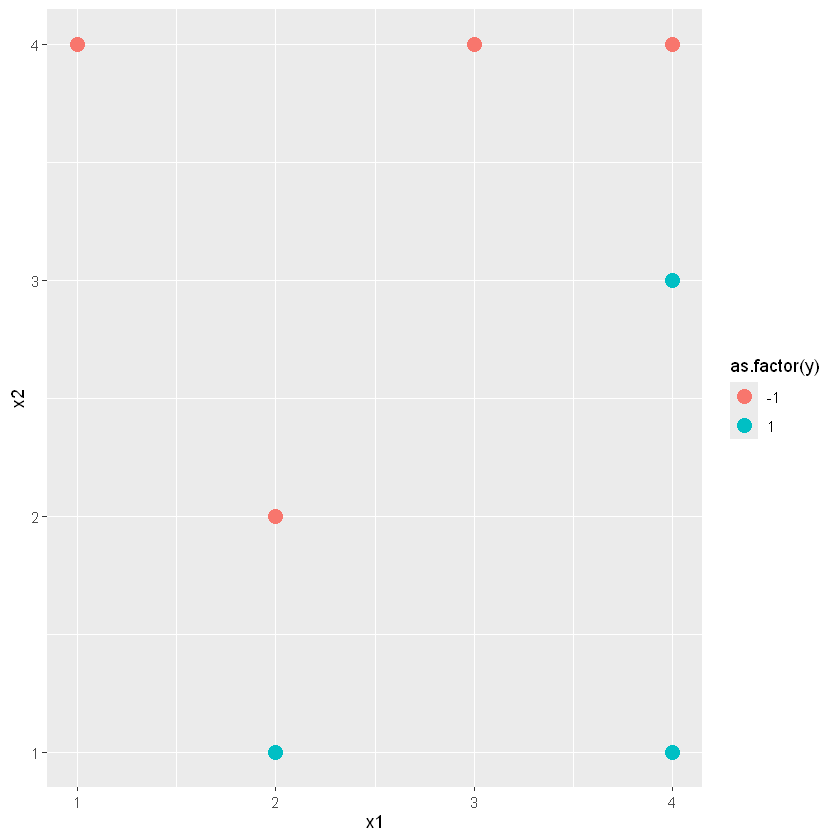

In [11]:
library(ggplot2)

data=data.frame(x1=c(3,2,4,1,2,4,4),x2=c(4,2,4,4,1,3,1),y=c(-1,-1,-1,-1,1,1,1))
ggplot(data, aes(x=x1,y=x2,col=as.factor(y))) + geom_point(size=4)

## Part (b)

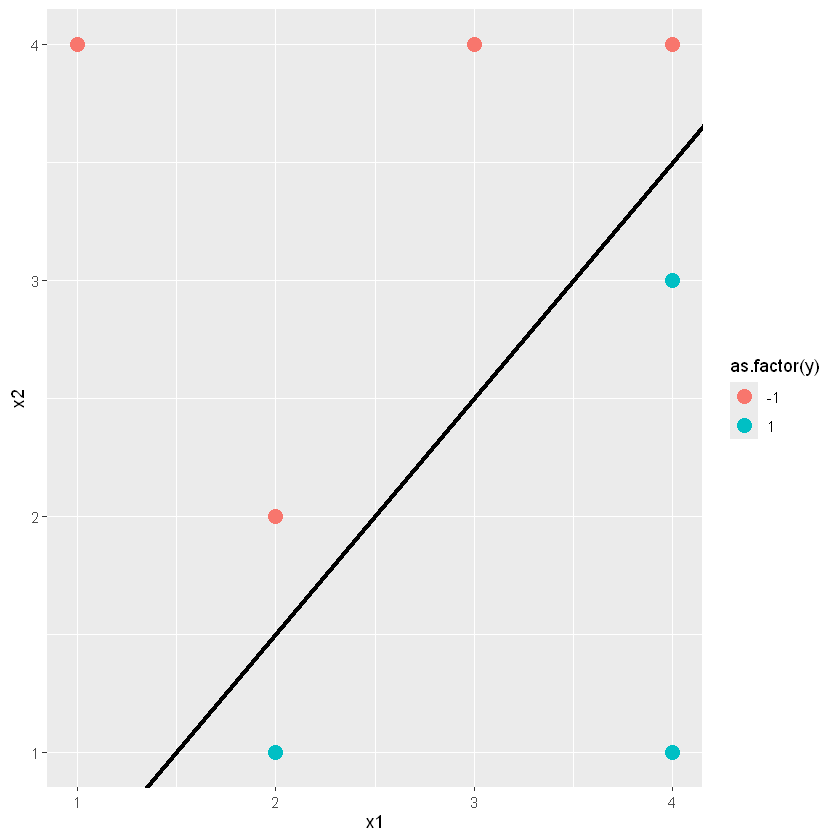

In [12]:
ggplot(data, aes(x=x1,y=x2,col=as.factor(y))) + geom_point(size=4) + geom_abline(slope=1,intercept=-0.5, linewidth=1.2)

The equation for the hyperplane sketched above is:
$$1 - 2X_1 + 2X_2 = 0$$

## Part (c)

As seen above, we classify to Red if $1 - 2X_1 + 2X_2 > 0$ and we classify to Blue if $1 - 2X_1 + 2X_2 < 0$.

## Part (d)

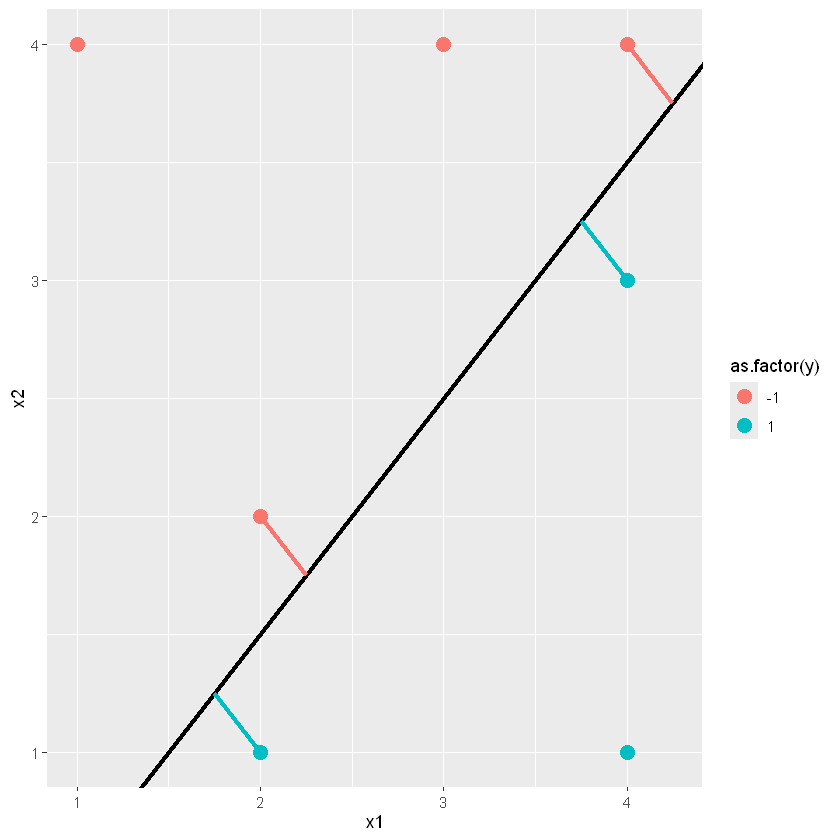

In [13]:
library(scales)

ggplot_palette = hue_pal()(8)
red = ggplot_palette[1]
blue = ggplot_palette[5]
yellow = "#FDE688"

ggplot(data, aes(x=x1,y=x2,col=as.factor(y))) + geom_point(size=4) + geom_abline(slope=1,intercept=-0.5, linewidth=1.2) +
    annotate("segment", x=2,y=1,xend=1.75,yend=1.25, linewidth=1.2, col=blue) +
    annotate("segment", x=2,y=2,xend=2.25,yend=1.75, linewidth=1.2, col=red) +
    annotate("segment", x=4,y=3,xend=3.75,yend=3.25, linewidth=1.2, col=blue) +
    annotate("segment", x=4,y=4,xend=4.25,yend=3.75, linewidth=1.2, col=red)

## Part (e)

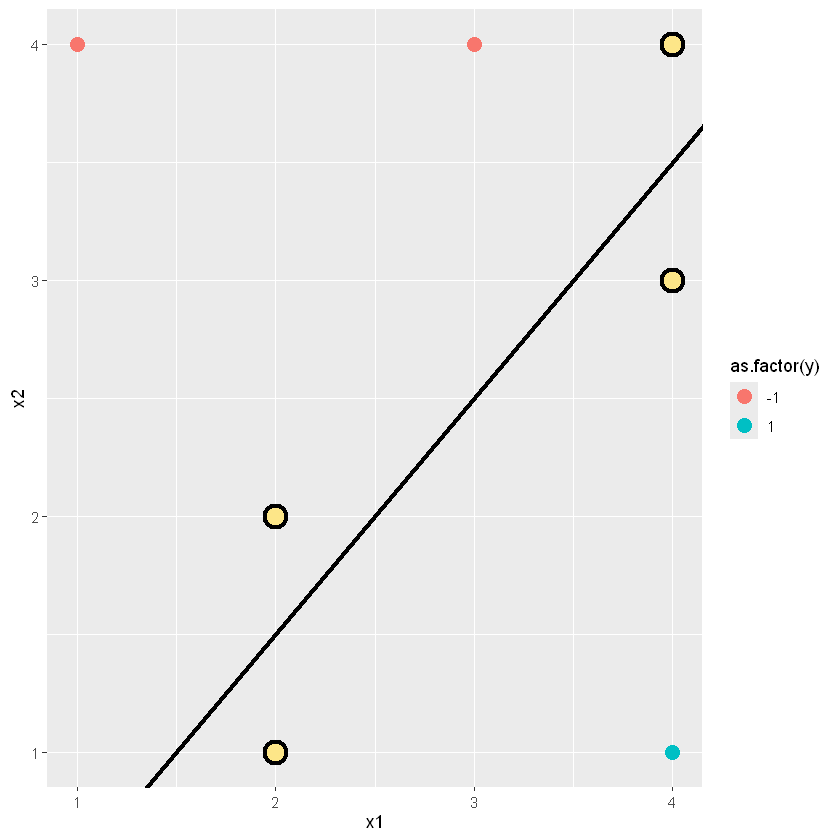

In [14]:
library(scales)

ggplot_palette = hue_pal()(8)
support_vectors = data[c(2,3,5,6),]

ggplot(data, aes(x=x1,y=x2,col=as.factor(y))) + geom_point(size=4) + geom_abline(slope=1,intercept=-0.5, linewidth=1.2) +
    geom_point(data=support_vectors, aes(x=x1, y=x2), color="black", fill=yellow, size=5, shape=21, stroke=2)


## Part (f)

The maximal margin classifier only depends on the support vectors (points that are exactly the margin away from the hyperplane). Since the 7th observation (bottom right blue point) is not one of the support vectors highlighted above, moving it slightly (but keeping it outside fo the margin) will not change the classifier.

## Part (g)

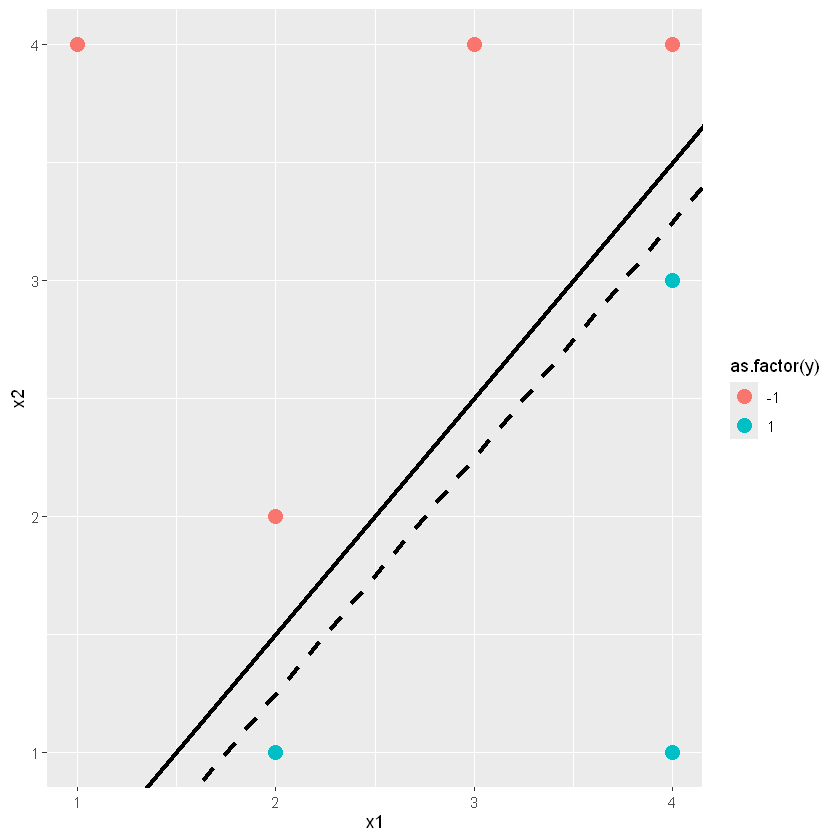

In [15]:
ggplot(data, aes(x=x1,y=x2,col=as.factor(y))) + geom_point(size=4) +
    geom_abline(slope=1,intercept=-0.5, linewidth=1.2) +
    geom_abline(slope=1,intercept=-0.75, linewidth=1.2, linetype="dashed")

## Part (h)

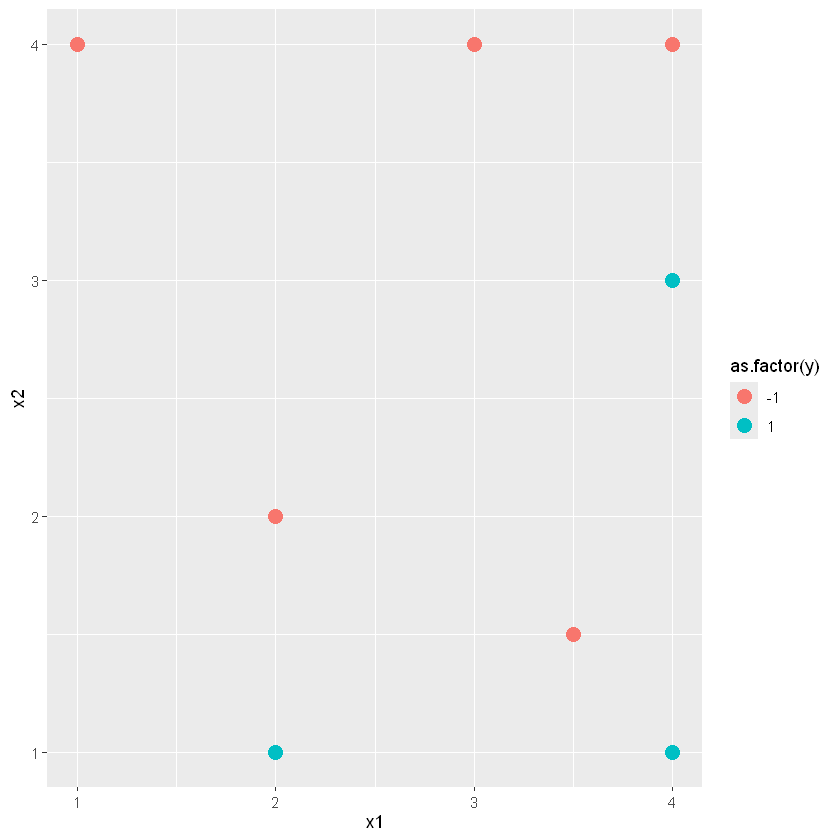

In [16]:
data[8,] = c(3.5,1.5,-1)
ggplot(data, aes(x=x1,y=x2,col=as.factor(y))) + geom_point(size=4)

# Exercise 7

In [1]:
library(ISLR)
fix(Auto)

## Part (a)

In [2]:
Auto$med_mpg = as.factor(ifelse(Auto$mpg > median(Auto$mpg), 1, 0))
Auto = Auto[,-1]

## Part (b)

In [3]:
library(e1071)

set.seed(1)
tune.out=tune(svm ,med_mpg~.,data=Auto ,kernel ="linear",ranges=list(cost=c (0.001, 0.01, 0.1, 1,5,10,100) ))
summary(tune.out)

Warning message:
"package 'e1071' was built under R version 4.5.2"



Parameter tuning of 'svm':

- sampling method: 10-fold cross validation 

- best parameters:
 cost
  0.1

- best performance: 0.08673077 

- Detailed performance results:
   cost      error dispersion
1 1e-03 0.13525641 0.05661708
2 1e-02 0.08923077 0.04698309
3 1e-01 0.08673077 0.04040897
4 1e+00 0.09961538 0.04923181
5 5e+00 0.11230769 0.05826857
6 1e+01 0.11237179 0.05701890
7 1e+02 0.11750000 0.06208951


It seems that a cost of 0.1 results in the lowest error of 0.087

## Part (c)

In [4]:
rad.out=tune(svm ,med_mpg~.,data=Auto ,kernel ="radial",
              ranges=list(cost=c(0.001, 0.01, 0.1, 1,5,10,100),
                          gamma=c(0.001, 0.01, 0.1,0.5,1,2,3,4)))

In [5]:
summary(rad.out)
summary(rad.out$best.model)


Parameter tuning of 'svm':

- sampling method: 10-fold cross validation 

- best parameters:
 cost gamma
    5   0.1

- best performance: 0.07891026 

- Detailed performance results:
    cost gamma      error dispersion
1  1e-03 0.001 0.55878205 0.04026862
2  1e-02 0.001 0.55878205 0.04026862
3  1e-01 0.001 0.55878205 0.04026862
4  1e+00 0.001 0.11448718 0.05970622
5  5e+00 0.001 0.08653846 0.04652039
6  1e+01 0.001 0.08653846 0.04326593
7  1e+02 0.001 0.08903846 0.04939961
8  1e-03 0.010 0.55878205 0.04026862
9  1e-02 0.010 0.55878205 0.04026862
10 1e-01 0.010 0.11448718 0.05970622
11 1e+00 0.010 0.08653846 0.04326593
12 5e+00 0.010 0.08903846 0.04308028
13 1e+01 0.010 0.08653846 0.04652039
14 1e+02 0.010 0.08403846 0.03968202
15 1e-03 0.100 0.55878205 0.04026862
16 1e-02 0.100 0.24737179 0.06358513
17 1e-01 0.100 0.08910256 0.04967202
18 1e+00 0.100 0.08653846 0.04326593
19 5e+00 0.100 0.07891026 0.03447059
20 1e+01 0.100 0.07903846 0.03051601
21 1e+02 0.100 0.10705128 0.04768453
22


Call:
best.tune(METHOD = svm, train.x = med_mpg ~ ., data = Auto, ranges = list(cost = c(0.001, 
    0.01, 0.1, 1, 5, 10, 100), gamma = c(0.001, 0.01, 0.1, 0.5, 1, 
    2, 3, 4)), kernel = "radial")


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  5 

Number of Support Vectors:  128

 ( 60 68 )


Number of Classes:  2 

Levels: 
 0 1




In [6]:
poly.out=tune(svm ,med_mpg~.,data=Auto ,kernel ="polynomial",
              ranges=list(cost=c(0.001, 0.01, 0.1, 1,5,10,100),
                          degree=c(1,2,3,4,5)))

In [7]:
summary(poly.out)
summary(poly.out$best.model)


Parameter tuning of 'svm':

- sampling method: 10-fold cross validation 

- best parameters:
 cost degree
    5      1

- best performance: 0.09198718 

- Detailed performance results:
    cost degree      error dispersion
1  1e-03      1 0.53141026 0.12668219
2  1e-02      1 0.53141026 0.12668219
3  1e-01      1 0.30435897 0.13243203
4  1e+00      1 0.10743590 0.05665916
5  5e+00      1 0.09198718 0.04717071
6  1e+01      1 0.10224359 0.06172755
7  1e+02      1 0.09205128 0.04881925
8  1e-03      2 0.55141026 0.07293170
9  1e-02      2 0.55141026 0.07293170
10 1e-01      2 0.55141026 0.07293170
11 1e+00      2 0.55141026 0.07293170
12 5e+00      2 0.55141026 0.07293170
13 1e+01      2 0.53602564 0.07705224
14 1e+02      2 0.30903846 0.10229240
15 1e-03      3 0.55141026 0.07293170
16 1e-02      3 0.55141026 0.07293170
17 1e-01      3 0.55141026 0.07293170
18 1e+00      3 0.55141026 0.07293170
19 5e+00      3 0.55141026 0.07293170
20 1e+01      3 0.55141026 0.07293170
21 1e+02      3 


Call:
best.tune(METHOD = svm, train.x = med_mpg ~ ., data = Auto, ranges = list(cost = c(0.001, 
    0.01, 0.1, 1, 5, 10, 100), degree = c(1, 2, 3, 4, 5)), kernel = "polynomial")


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  polynomial 
       cost:  5 
     degree:  1 
     coef.0:  0 

Number of Support Vectors:  148

 ( 73 75 )


Number of Classes:  2 

Levels: 
 0 1




The best radial model (cost=5, gamma=0.15) has an error of 0.079 which is better than the linear kernel. The best polynomial model actually turned out to be linear (although it differs from the linear kernel by a constant) with degree 1 and cost 5 and an error of 0.084 - which is barely better than linear.

## Part (d)

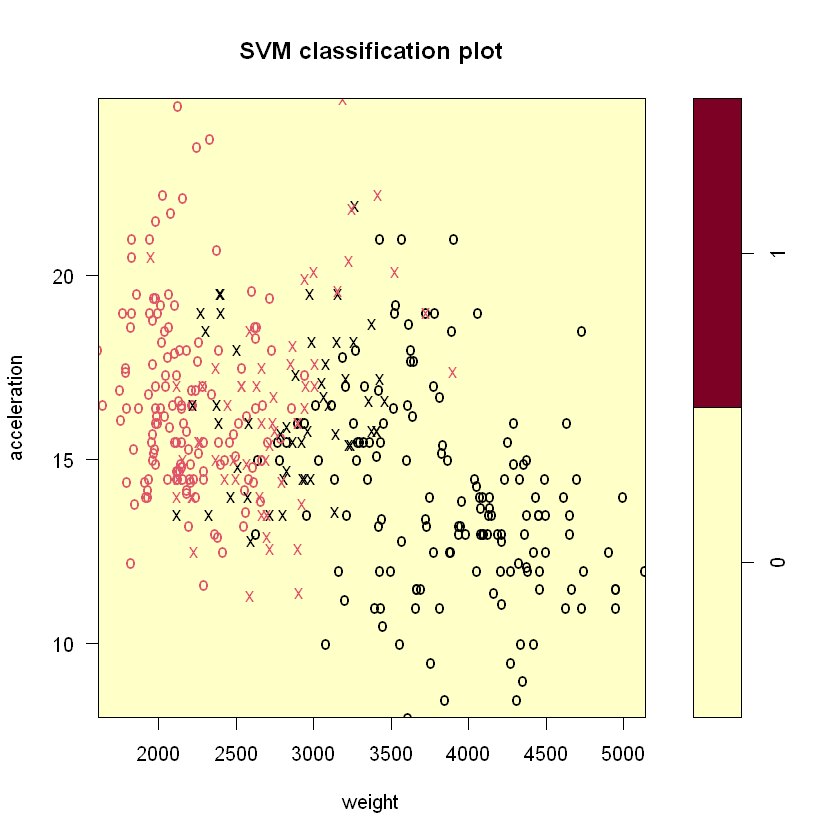

In [8]:
plot(tune.out$best.model , Auto, acceleration~weight)

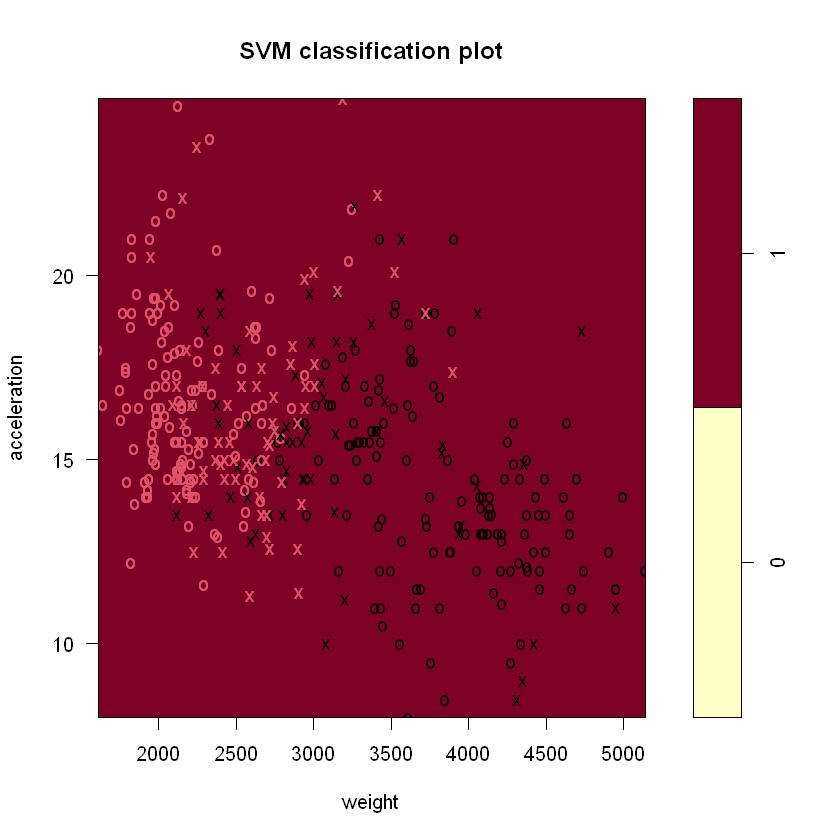

In [9]:
plot(rad.out$best.model , Auto, acceleration~weight)

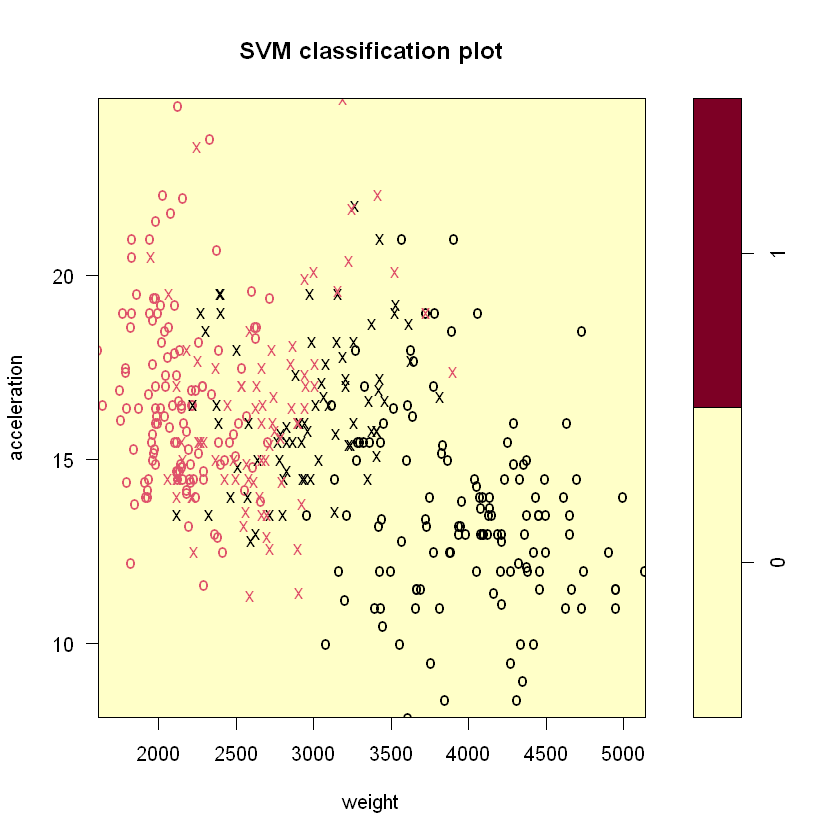

In [10]:
plot(poly.out$best.model , Auto, acceleration~weight)

We can see that these basic plots for accelerations vs weight match our results in (b) and (c). The support vecotrs for the linear and polynomial kernels are almost identical - and only a few of the vectors actually contribute to the decision boundary. The radial one has support vectors surrounding each of the 3 or so main clusters in the plot (2 black and 1 red) allowing for higher accuracy in predicting if a data point falls in each one of these clusters.